# Customer Experience Analytics Platform

## Business Objective

The objective of this project is to analyze customer satisfaction data to identify key drivers of customer experience, uncover improvement opportunities, and develop actionable business insights.

This project simulates a real-world analytics engagement where business stakeholders require data-driven recommendations to improve customer satisfaction and operational performance.

## Project Goals

- Assess data quality and completeness
- Understand customer satisfaction patterns
- Identify key drivers of satisfaction
- Perform customer segmentation analysis
- Build a foundation for dashboarding and reporting
- Develop recommendations supported by data

## Current Phase

Data Ingestion and Initial Data Profiling

## Data Loading

### Objective

The first step in the analytics process is to load the raw dataset into a Pandas DataFrame.

This allows us to:

- Understand the structure of the data
- Review available attributes
- Assess data quality
- Prepare for exploratory analysis

### Expected Outcome

Successfully load the dataset and validate that the data is accessible for further analysis.

In [4]:

import pandas as pd


## Load Dataset

### Objective

Load the customer satisfaction dataset into a Pandas DataFrame and validate that the data is accessible for analysis.

### Reason for Action

Before performing any exploratory analysis, we need to understand the structure of the dataset and verify that the data has been loaded correctly.

In [5]:
df = pd.read_csv("/Users/sunny/Projects/customer-experience-analytics/data/train.csv")

df.head()

,Unnamed: 0,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,...,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied
1,1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,...,1,1,5,3,1,4,1,1,6.0,neutral or dissatisfied
2,2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,...,5,4,3,4,4,4,5,0,0.0,satisfied
3,3,24026,Female,Loyal Customer,25,Business travel,Business,562,2,5,...,2,2,5,3,1,4,2,11,9.0,neutral or dissatisfied
4,4,119299,Male,Loyal Customer,61,Business travel,Business,214,3,3,...,3,3,4,4,3,3,3,0,0.0,satisfied


### Initial Observations

The dataset was successfully loaded into a Pandas DataFrame.

A preliminary review indicates that the dataset contains customer demographic information, travel characteristics, service quality ratings, and customer satisfaction-related attributes.

An additional column named `Unnamed: 0` appears to be a technical index field rather than a business attribute and will be evaluated to be removed/kept during the data cleaning phase.

## Dataset Size Assessment

### Objective

Determine the volume of data available for analysis by evaluating the number of records and attributes contained within the dataset.

### Reason for Action

Understanding dataset size helps assess the reliability of future analysis, the potential for customer segmentation, and the overall analytical scope of the project.

In [6]:
df.shape

(103904, 25)

### Observation

The dataset contains 103,904 customer records and 25 attributes.

The volume of available data is sufficient to support customer segmentation, satisfaction analysis, service performance evaluation, and dashboard development.

The dataset size is large enough to identify meaningful trends while remaining manageable for exploratory analysis and reporting purposes.

### Business Relevance

A dataset of this scale provides confidence that insights generated from the analysis will be representative of broader customer experience patterns and can be used to support data-driven recommendations.

## Dataset Structure Assessment

### Objective

Evaluate the structure of the dataset by reviewing available attributes, data types, and completeness of information.

### Reason for Action

Understanding dataset structure helps identify business dimensions, performance metrics, and potential data quality issues before conducting exploratory analysis.

The assessment will also help determine which fields require cleaning, transformation, or further investigation.

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103904 entries, 0 to 103903
Data columns (total 25 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Unnamed: 0                         103904 non-null  int64  
 1   id                                 103904 non-null  int64  
 2   Gender                             103904 non-null  object 
 3   Customer Type                      103904 non-null  object 
 4   Age                                103904 non-null  int64  
 5   Type of Travel                     103904 non-null  object 
 6   Class                              103904 non-null  object 
 7   Flight Distance                    103904 non-null  int64  
 8   Inflight wifi service              103904 non-null  int64  
 9   Departure/Arrival time convenient  103904 non-null  int64  
 10  Ease of Online booking             103904 non-null  int64  
 11  Gate location                      1039

### Observation

The dataset contains a combination of demographic, travel behavior, service quality, and satisfaction-related attributes.

Initial profiling indicates a high level of data completeness across the dataset. Most attributes contain data for all 103,904 records.

One exception was identified in the `Arrival Delay in Minutes` field, which contains missing values and will require further investigation during the data quality assessment phase.

An additional column named `Unnamed: 0` appears to be a technical index field rather than a business attribute and is a candidate for removal during data preparation.

### Business Relevance

The available attributes provide sufficient information to evaluate customer satisfaction across different customer segments, travel classes, and service dimensions. The dataset structure supports both descriptive analysis and the development of executive reporting dashboards.

In [8]:
df.isnull().sum()

Unnamed: 0                             0
id                                     0
Gender                                 0
Customer Type                          0
Age                                    0
Type of Travel                         0
Class                                  0
Flight Distance                        0
Inflight wifi service                  0
Departure/Arrival time convenient      0
Ease of Online booking                 0
Gate location                          0
Food and drink                         0
Online boarding                        0
Seat comfort                           0
Inflight entertainment                 0
On-board service                       0
Leg room service                       0
Baggage handling                       0
Checkin service                        0
Inflight service                       0
Cleanliness                            0
Departure Delay in Minutes             0
Arrival Delay in Minutes             310
satisfaction    

## Data Quality Assessment

### Objective

Assess the completeness of the dataset by identifying missing values and evaluating their potential impact on analysis.

### Reason for Action

Missing values can influence analytical outcomes and may introduce bias if not handled appropriately.

Understanding the scale and location of missing data helps determine the most suitable data preparation strategy.

### Observation

The dataset exhibits a high level of completeness, with only one attribute containing missing values.

The `Arrival Delay in Minutes` field contains 310 missing records out of 103,904 total observations, representing approximately 0.3% of the dataset.

No missing values were identified in any other attribute.

### Business Relevance

The limited number of missing records suggests that data quality is generally strong and is unlikely to materially impact downstream analysis.

The missing arrival delay records will be investigated further before selecting an appropriate treatment strategy.

## Customer Satisfaction Assessment

### Objective

Understand the distribution of customer satisfaction outcomes and establish a baseline view of overall customer sentiment.

### Reason for Action

Customer satisfaction represents the primary business outcome of interest within this dataset.

Understanding the balance between satisfied and dissatisfied customers provides context for subsequent analysis and helps identify opportunities for service improvement.

In [9]:
df["satisfaction"].value_counts()

satisfaction
neutral or dissatisfied    58879
satisfied                  45025
Name: count, dtype: int64

### Observation

The customer satisfaction variable contains two outcome categories:

- Satisfied
- Neutral or Dissatisfied

The largest customer group falls within the Neutral or Dissatisfied category, accounting for 58,879 customers compared to 45,025 customers classified as Satisfied.

### Business Relevance

The distribution suggests that a substantial proportion of customers are not reporting highly positive experiences.

Understanding the factors associated with customer satisfaction will be critical for identifying improvement opportunities and supporting customer experience initiatives.

In [10]:
df["satisfaction"].value_counts(normalize=True) * 100

satisfaction
neutral or dissatisfied    56.666731
satisfied                  43.333269
Name: proportion, dtype: float64

### Observation

Approximately 56.7% of customers were classified as Neutral or Dissatisfied, while 43.3% were classified as Satisfied.

The results indicate that less than half of customers reported a fully satisfactory experience.

### Business Relevance

The distribution highlights a significant opportunity for customer experience improvement.

Because a majority of customers are not reporting highly positive experiences, identifying the factors associated with satisfaction will be critical for prioritizing operational and service enhancements.

## Delay Impact Assessment

### Objective

Evaluate whether flight delays are associated with customer satisfaction outcomes.

### Reason for Action

Operational delays are often considered a major source of customer frustration.

Assessing the relationship between delays and satisfaction helps determine whether punctuality should be prioritized as a customer experience improvement initiative.

In [11]:
df.groupby("satisfaction")["Arrival Delay in Minutes"].mean()

satisfaction
neutral or dissatisfied    17.127536
satisfied                  12.630799
Name: Arrival Delay in Minutes, dtype: float64

### Observation

Customers classified as Neutral or Dissatisfied experienced an average arrival delay of approximately 17.1 minutes, compared to 12.6 minutes for Satisfied customers.

The results indicate that delayed arrivals are associated with lower satisfaction levels.

### Business Relevance

Although customers experiencing lower satisfaction report higher average delays, the difference is relatively modest. This suggests that operational delays may contribute to customer sentiment but are unlikely to fully explain satisfaction outcomes on their own.

Additional service-related and customer experience factors should be investigated.

In [12]:
df.groupby("satisfaction")["Seat comfort"].mean()

satisfaction
neutral or dissatisfied    3.036295
satisfied                  3.966530
Name: Seat comfort, dtype: float64

### Observation

Satisfied customers reported an average seat comfort rating of approximately 3.97, compared to 3.04 among Neutral or Dissatisfied customers.

The difference of nearly one rating point suggests a meaningful relationship between perceived seat comfort and overall customer satisfaction.

### Business Relevance

The results indicate that service quality factors may play an important role in shaping customer sentiment.

Improving physical comfort during travel could represent a potential opportunity to increase customer satisfaction levels.

In [13]:
df.groupby("satisfaction")[[
    "Inflight wifi service",
    "Seat comfort",
    "Inflight entertainment",
    "Online boarding",
    "Food and drink"
]].mean()

,Inflight wifi service,Seat comfort,Inflight entertainment,Online boarding,Food and drink
satisfaction,,,,,
neutral or dissatisfied,2.399633,3.036295,2.894156,2.656125,2.95805
satisfied,3.161288,3.966530,3.964931,4.027474,3.52131


## Service Quality Driver Assessment

### Objective

Identify service-related attributes that exhibit the strongest relationship with customer satisfaction outcomes.

### Observation

All evaluated service quality metrics received higher ratings among satisfied customers.

The largest differences were observed in:

1. Online Boarding
2. Inflight Entertainment
3. Seat Comfort

Online Boarding demonstrated the strongest separation between satisfied and dissatisfied customers.

### Business Relevance

The findings suggest that digital experience and service delivery factors may have a greater influence on customer satisfaction than operational delays alone.

Improving customer-facing service interactions could represent a high-impact opportunity for increasing satisfaction levels.

# Satisfaction Distribution Visualization

### Objective

Visualize the distribution of customer satisfaction outcomes.

### Reason for Action

Visual representations provide a clearer understanding of customer sentiment and help communicate findings effectively to business stakeholders.

Matplotlib is building the font cache; this may take a moment.


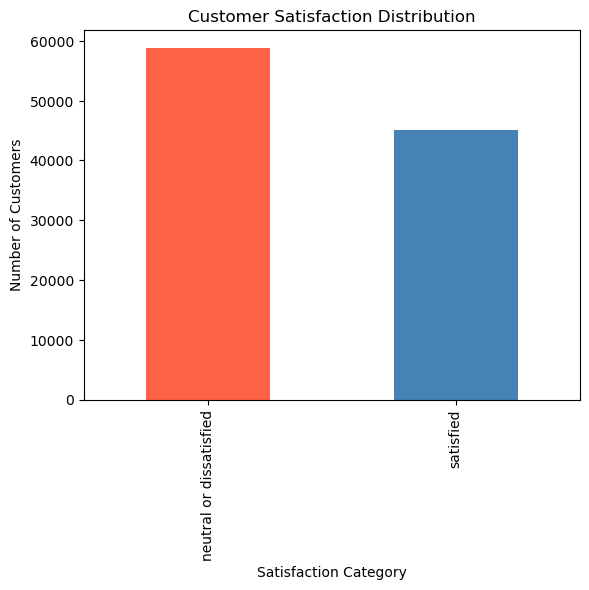

In [14]:
import matplotlib.pyplot as plt

df["satisfaction"].value_counts().plot(
    kind="bar",
    color=["tomato", "steelblue"]
)

plt.title("Customer Satisfaction Distribution")
plt.xlabel("Satisfaction Category")
plt.ylabel("Number of Customers")

plt.show()

### Observation

The visualization confirms that the Neutral or Dissatisfied customer segment exceeds the Satisfied customer segment.

The difference is substantial, indicating that a majority of customers are not reporting highly positive travel experiences.

### Business Relevance

The distribution highlights a significant customer experience improvement opportunity.

Increasing the proportion of satisfied customers should be a primary business objective, and further analysis is required to identify the factors contributing to customer sentiment.

# Service Driver Comparison

### Objective

Compare key service quality metrics between satisfied and neutral/dissatisfied customers.

### Reason for Action

Understanding which service dimensions exhibit the largest differences can help prioritize customer experience improvement initiatives.

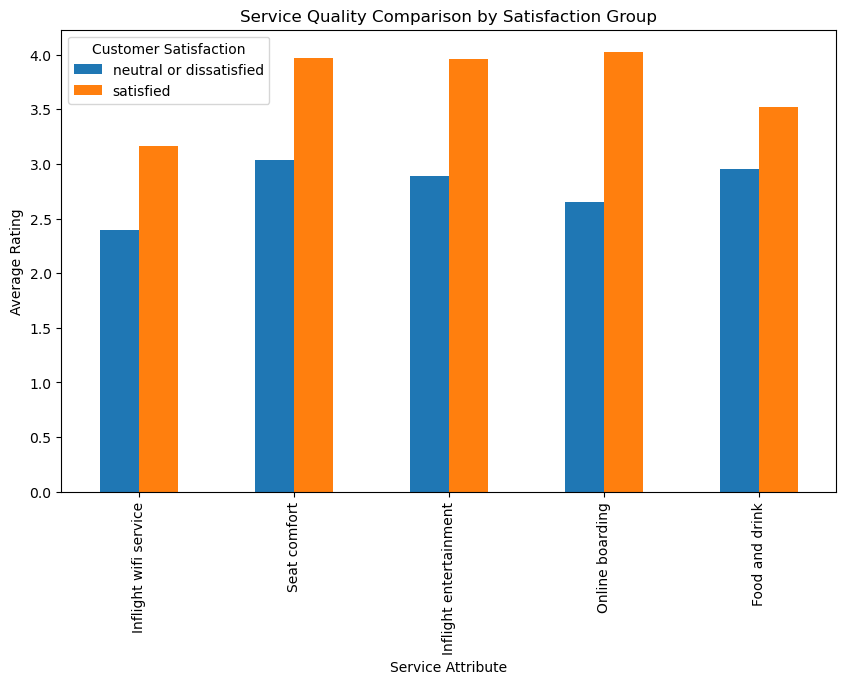

In [15]:
service_scores = df.groupby("satisfaction")[[
    "Inflight wifi service",
    "Seat comfort",
    "Inflight entertainment",
    "Online boarding",
    "Food and drink"
]].mean()

service_scores.T.plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Service Quality Comparison by Satisfaction Group")
plt.ylabel("Average Rating")
plt.xlabel("Service Attribute")
plt.legend(title="Customer Satisfaction")

plt.show()

## Customer Segment Analysis

### Key Question

Are Loyal Customers more satisfied than Disloyal Customers?

In [16]:
pd.crosstab(
    df["Customer Type"],
    df["satisfaction"],
    normalize="index"
) * 100

satisfaction,neutral or dissatisfied,satisfied
Customer Type,,
Loyal Customer,52.270881,47.729119
disloyal Customer,76.334229,23.665771


### Key Insight

Loyal customers report significantly higher satisfaction levels than disloyal customers.

Approximately 47.7% of loyal customers are satisfied compared to only 23.7% of disloyal customers.

However, a majority of loyal customers still fall into the Neutral or Dissatisfied category, suggesting that customer loyalty alone is not sufficient to ensure a positive customer experience.

### Business Impact

Customer loyalty appears to be strongly associated with satisfaction outcomes.

However, the findings indicate an opportunity to improve the experience of existing loyal customers, which could strengthen retention and advocacy over time.

In [17]:
pd.crosstab(
    df["Class"],
    df["satisfaction"],
    normalize="index"
) * 100

satisfaction,neutral or dissatisfied,satisfied
Class,,
Business,30.574852,69.425148
Eco,81.386245,18.613755
Eco Plus,75.393648,24.606352


### Key Insight

Customer satisfaction varies significantly across travel classes.

Business Class customers report the highest satisfaction rate at approximately 69.4%, while Eco Plus and Eco customers report satisfaction rates of 24.6% and 18.6%, respectively.

The magnitude of the difference suggests that travel class is strongly associated with customer satisfaction outcomes.

### Business Impact

The findings indicate that premium travel experiences are associated with substantially higher customer satisfaction.

Understanding which aspects of the Business Class experience drive satisfaction may help identify opportunities to improve the experience for Economy and Eco Plus passengers.

# Executive Summary

## Project Objective

The objective of this analysis was to identify key factors influencing customer satisfaction within the airline travel experience and provide actionable insights that support customer experience improvement initiatives.

## Key Findings

### 1. Customer Satisfaction Opportunity

Approximately 56.7% of customers were classified as Neutral or Dissatisfied, indicating significant room for improvement in the overall customer experience.

### 2. Operational Delays Impact Satisfaction

Customers classified as Neutral or Dissatisfied experienced higher average arrival delays compared to Satisfied customers. While the difference was measurable, delays alone do not fully explain customer sentiment.

### 3. Service Quality Drives Satisfaction

Service-related attributes demonstrated stronger relationships with customer satisfaction than operational delays.

The largest differences between satisfied and dissatisfied customers were observed in:

- Online Boarding
- Inflight Entertainment
- Seat Comfort

### 4. Customer Loyalty Matters

Loyal customers reported substantially higher satisfaction levels than disloyal customers.

However, more than half of loyal customers still fell into the Neutral or Dissatisfied category, suggesting additional opportunities to improve the customer experience.

### 5. Travel Class Strongly Influences Satisfaction

Business Class customers reported significantly higher satisfaction rates than Economy and Eco Plus customers.

This suggests that aspects of the premium travel experience may provide valuable insights into improving satisfaction across other customer segments.

## Business Recommendations

1. Prioritize improvements to the online boarding experience.

2. Continue monitoring operational delays and identify opportunities to reduce arrival disruptions.

3. Invest in customer experience initiatives related to comfort, entertainment, and service quality.

4. Conduct deeper analysis of Business Class service features to identify practices that could be adapted for Economy passengers.

5. Develop targeted retention and engagement strategies for loyal customers who continue to report neutral or dissatisfied experiences.

## Next Steps

Future analysis could include:

- Predictive modeling of customer satisfaction using machine learning.
- Driver importance analysis to quantify the impact of individual service attributes.
- Interactive dashboard development using Power BI.
- Segment-level analysis by age, travel type, and customer demographics.

### Fixing Schema for GCP

In [18]:
df.columns

Index(['Unnamed: 0', 'id', 'Gender', 'Customer Type', 'Age', 'Type of Travel',
       'Class', 'Flight Distance', 'Inflight wifi service',
       'Departure/Arrival time convenient', 'Ease of Online booking',
       'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort',
       'Inflight entertainment', 'On-board service', 'Leg room service',
       'Baggage handling', 'Checkin service', 'Inflight service',
       'Cleanliness', 'Departure Delay in Minutes', 'Arrival Delay in Minutes',
       'satisfaction'],
      dtype='object')

In [19]:
df.columns = [
    'Unnamed_0',
    'id',
    'Gender',
    'Customer_Type',
    'Age',
    'Type_of_Travel',
    'Class',
    'Flight_Distance',
    'Inflight_wifi_service',
    'Departure_Arrival_time_convenient',
    'Ease_of_Online_booking',
    'Gate_location',
    'Food_and_drink',
    'Online_boarding',
    'Seat_comfort',
    'Inflight_entertainment',
    'On_board_service',
    'Leg_room_service',
    'Baggage_handling',
    'Checkin_service',
    'Inflight_service',
    'Cleanliness',
    'Departure_Delay_in_Minutes',
    'Arrival_Delay_in_Minutes',
    'satisfaction'
]

In [20]:
df.to_csv('../data/train_clean.csv', index=False)

# Google Cloud Platform (GCP) Integration

## Objective

Load the airline customer satisfaction dataset into Google BigQuery to enable cloud-based SQL analysis and demonstrate enterprise-scale analytics capabilities.

## Reason for Action

Organizations commonly store analytical datasets in cloud data warehouses rather than local files. Integrating BigQuery allows scalable querying, centralized data management, and supports downstream reporting and dashboarding solutions.

## Actions Performed

- Created a Google Cloud Platform project
- Created a Cloud Storage bucket
- Uploaded source CSV files to Cloud Storage
- Standardized column names for BigQuery compatibility
- Loaded the dataset into a BigQuery table

## Outcome

The dataset was successfully loaded into BigQuery and is now available for SQL-based analysis.